# Finite Elements in 1D (Didactic Core)

We solve $-u''(x)=f(x)$ on $(0,1)$ with Dirichlet boundary conditions using piecewise-linear finite elements.
The weak form reads
$$
\int_0^1 u'(x)v'(x)\,dx = \int_0^1 f(x)v(x)\,dx \quad \forall v\in H_0^1.
$$


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/fem-1d-2d") if Path("python/fem-1d-2d").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


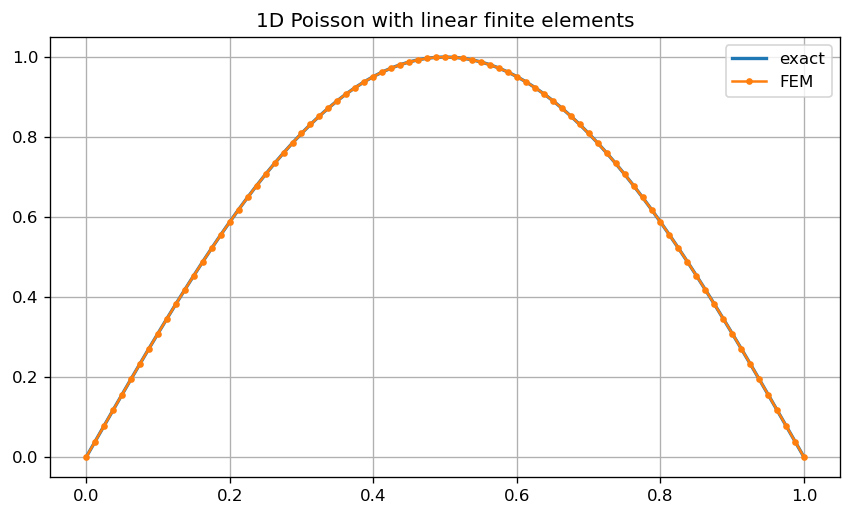

In [2]:
n = 80
x = np.linspace(0, 1, n+1)
h = x[1]-x[0]

f = lambda z: np.pi**2*np.sin(np.pi*z)  # exact u=sin(pi x)
u_exact = np.sin(np.pi*x)

N = n-1  # interior dof
K = np.zeros((N, N))
b = np.zeros(N)

for e in range(n):
    xL, xR = x[e], x[e+1]
    Ke = (1/h)*np.array([[1, -1], [-1, 1]])
    # midpoint quadrature on each basis contribution
    xm = 0.5*(xL+xR)
    fe = f(xm)*h*0.5*np.array([1, 1])
    idx = [e-1, e]  # map to interior indexing
    for a in range(2):
        ia = idx[a]
        if 0 <= ia < N:
            b[ia] += fe[a]
            for c in range(2):
                ic = idx[c]
                if 0 <= ic < N:
                    K[ia, ic] += Ke[a, c]

u_int = np.linalg.solve(K, b)
u = np.zeros(n+1); u[1:-1] = u_int

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(x, u_exact, lw=2, label="exact")
ax.plot(x, u, "o-", ms=3, lw=1.5, label="FEM")
ax.set_title("1D Poisson with linear finite elements")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. Nocedal and S. Wright, *Numerical Optimization*.
- L. N. Trefethen, *Finite Difference and Spectral Methods* (lecture notes).
- D. P. Bertsekas, *Nonlinear Programming*.
